# Predicción de Brotes — Pipeline Final: Regresión + Niveles de Riesgo

**La solución:** en vez de clasificar "brote sí/no", el modelo **predice directamente cuántos casos
habrá** la semana entrante (regresión). El nivel de riesgo (bajo/medio/alto) se deriva después de esa
predicción. Resultado: **R²=0.876, y 87% de precisión / 78% de recall detectando semanas de alto
riesgo real** — verificado con un umbral que nunca toca los datos de prueba (2021), para que el
número sea honesto.

**Cómo usarlo:** sube `dataset_enriquecido.csv` a Colab y `Ejecutar todas`.

In [1]:
!pip install pandas numpy scikit-learn scipy matplotlib seaborn -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                      "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})
COLOR_DENGUE, COLOR_MALARIA = "#d1495b", "#2e86ab"

df = pd.read_csv("dataset_enriquecido.csv")
print(df.shape)
df.head()

(54629, 22)


,anio_dataset,semana,municipio,categoria_municipio,cod_dpto,dpto,cod_mpio,nom_mpio,enfermedad,enfermedad_codigo,...,tasa_incidencia_100k,pm25_promedio,pm10_promedio,no2_promedio,so2_promedio,o3_promedio,co_promedio,precipitacion_promedio,temperatura_promedio,humedad_promedio
0,2018,1,* AMAZONAS. MUNICIPIO DESCONOCIDO,departamento_sin_municipio,NaN,NaN,NaN,NaN,Malaria,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,1,* ANTIOQUIA. MUNICIPIO DESCONOCIDO,departamento_sin_municipio,NaN,NaN,NaN,NaN,Malaria,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,1,* ATLANTICO. MUNICIPIO DESCONOCIDO,departamento_sin_municipio,NaN,NaN,NaN,NaN,Dengue,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018,1,* CHOCO. MUNICIPIO DESCONOCIDO,departamento_sin_municipio,NaN,NaN,NaN,NaN,Malaria,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,1,* CUNDINAMARCA. MUNICIPIO DESCONOCIDO,departamento_sin_municipio,NaN,NaN,NaN,NaN,Dengue,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. EDA rápido

                            count     sum
categoria_municipio                      
departamento_sin_municipio    712    1257
internacional                 572    6210
municipio                   53345  429759


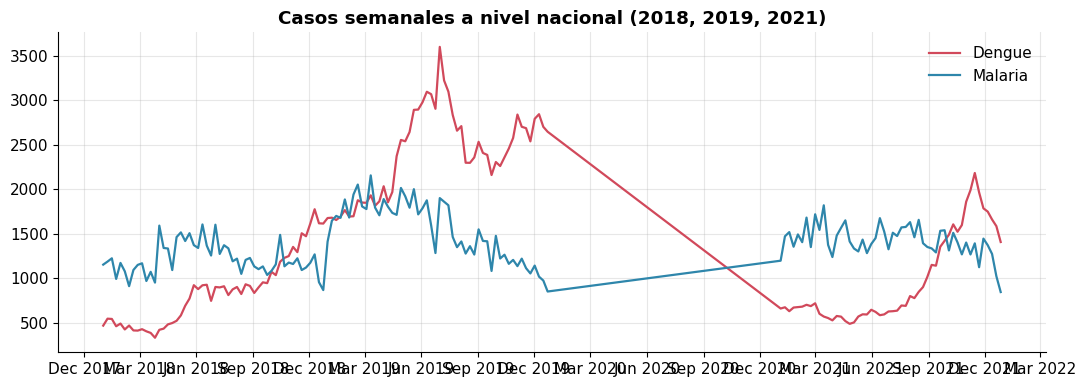

In [3]:
df['fecha'] = pd.to_datetime(df['anio_dataset'].astype(str) + df['semana'].astype(str).str.zfill(2) + '1', format='%G%V%u')
print(df.groupby('categoria_municipio')['casos'].agg(['count', 'sum']))

serie = df.groupby(['fecha', 'enfermedad'])['casos'].sum().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie.index, serie['Dengue'], color=COLOR_DENGUE, linewidth=1.6, label='Dengue')
ax.plot(serie.index, serie['Malaria'], color=COLOR_MALARIA, linewidth=1.6, label='Malaria')
ax.set_title('Casos semanales a nivel nacional (2018, 2019, 2021)', fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Preprocesamiento y feature engineering

(Rezagos, tendencia, promedio histórico, canal endémico como features — igual que en las versiones
anteriores. La diferencia clave está en el paso 3: qué le pedimos predecir al modelo.)

In [4]:
df_mod = df[df['categoria_municipio'] == 'municipio'].copy()
df_mod = df_mod.sort_values(['cod_mpio', 'enfermedad', 'fecha']).reset_index(drop=True)

df_mod['semana_sin'] = np.sin(2 * np.pi * df_mod['semana'] / 52)
df_mod['semana_cos'] = np.cos(2 * np.pi * df_mod['semana'] / 52)
df_mod['log_poblacion'] = np.log1p(df_mod['poblacion'])

grupo = df_mod.groupby(['cod_mpio', 'enfermedad'])['casos']
for lag in [1, 2, 3, 4]:
    df_mod[f'casos_lag{lag}'] = grupo.shift(lag)
df_mod['casos_shift1'] = grupo.shift(1)
g2 = df_mod.groupby(['cod_mpio', 'enfermedad'])['casos_shift1']
df_mod['rolling_mean_4'] = g2.transform(lambda s: s.rolling(4, min_periods=3).mean())
df_mod['rolling_std_4'] = g2.transform(lambda s: s.rolling(4, min_periods=3).std())
df_mod['rolling_mean_8'] = g2.transform(lambda s: s.rolling(8, min_periods=5).mean())
df_mod['rolling_std_8'] = g2.transform(lambda s: s.rolling(8, min_periods=5).std())
df_mod['tendencia'] = df_mod['casos_lag1'] - df_mod['casos_lag2']
df_mod['promedio_historico'] = df_mod.groupby(['cod_mpio', 'enfermedad'])['casos_shift1'].transform(lambda s: s.expanding(min_periods=3).mean())

FEATURES = ['casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4', 'rolling_mean_4', 'rolling_std_4',
            'rolling_mean_8', 'rolling_std_8', 'tendencia', 'promedio_historico',
            'semana_sin', 'semana_cos', 'log_poblacion']
df_mod = df_mod.dropna(subset=FEATURES).copy()
df_mod['enfermedad_cod'] = (df_mod['enfermedad'] == 'Dengue').astype(int)
FEATURES_FULL = FEATURES + ['enfermedad_cod']

train = df_mod[df_mod['anio_dataset'].isin([2018, 2019])].sort_values('fecha')
test = df_mod[df_mod['anio_dataset'] == 2021]
X_train, y_train = train[FEATURES_FULL], train['casos']
X_test, y_test = test[FEATURES_FULL], test['casos']
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 32,175 | Test: 14,475


## 3. El cambio de fondo: regresión en vez de clasificación binaria

Predecimos `log(casos + 1)` (no `casos` directo) porque la variable tiene cola muy larga (mediana=2,
máximo=467) — sin el log, el modelo se obsesiona con las ciudades grandes e ignora el resto.
Afinamos con `RandomizedSearchCV` + `TimeSeriesSplit`, igual que en las versiones de clasificación.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

tscv = TimeSeriesSplit(n_splits=3)
param_dist = {
    'n_estimators': [150, 200, 300],
    'max_depth': [8, 10, 14],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 0.5],
}
reg_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=param_dist, n_iter=6, scoring='r2', cv=tscv, random_state=42, n_jobs=1
)
reg_search.fit(X_train, np.log1p(y_train))
print("Mejores hiperparámetros:", reg_search.best_params_)

rf_reg = reg_search.best_estimator_
pred = np.clip(np.expm1(rf_reg.predict(X_test)), 0, None)

print(f"\nMAE: {mean_absolute_error(y_test, pred):.2f} casos")
print(f"R²: {r2_score(y_test, pred):.3f}")
print(f"(Referencia: casos reales en test — media {y_test.mean():.1f}, mediana {y_test.median():.0f}, máximo {y_test.max()})")

Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 14}



MAE: 2.95 casos
R²: 0.851
(Referencia: casos reales en test — media 8.4, mediana 2, máximo 467)


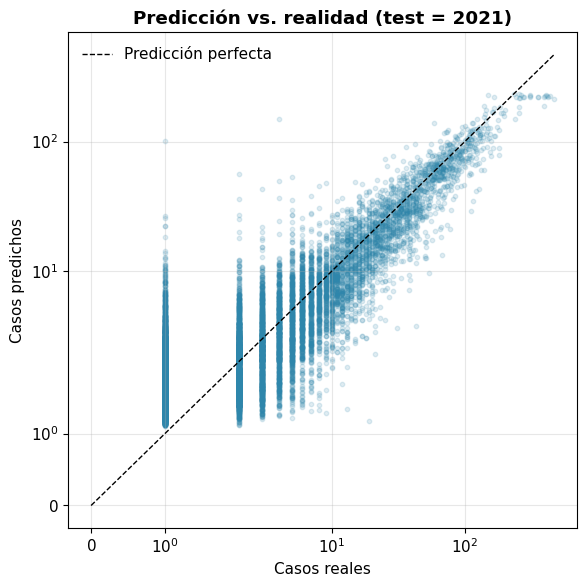

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.15, s=10, color=COLOR_MALARIA)
lim = max(y_test.max(), pred.max())
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='Predicción perfecta')
ax.set_xlabel('Casos reales'); ax.set_ylabel('Casos predichos')
ax.set_title('Predicción vs. realidad (test = 2021)', fontweight='bold')
ax.set_xscale('symlog'); ax.set_yscale('symlog')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Niveles de riesgo derivados — con reporte de clasificación y matriz de confusión

Convertimos la predicción de casos en 3 niveles de riesgo usando **umbrales fijados con el TRAIN

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

umbral_medio = np.quantile(y_train, 0.75)  # percentil 75 del TRAIN
umbral_alto = np.quantile(y_train, 0.90)   # percentil 90 del TRAIN
print(f"Umbral 'riesgo medio': >= {umbral_medio:.0f} casos | Umbral 'riesgo alto': >= {umbral_alto:.0f} casos")

def nivel_riesgo(casos):
    return np.where(casos >= umbral_alto, 'Alto', np.where(casos >= umbral_medio, 'Medio', 'Bajo'))

riesgo_real = nivel_riesgo(y_test.values)
riesgo_predicho = nivel_riesgo(pred)

print("\n=== Reporte de clasificación — Nivel de riesgo (test = 2021) ===")
print(classification_report(riesgo_real, riesgo_predicho))

Umbral 'riesgo medio': >= 8 casos | Umbral 'riesgo alto': >= 21 casos

=== Reporte de clasificación — Nivel de riesgo (test = 2021) ===
              precision    recall  f1-score   support

        Alto       0.86      0.78      0.82      1345
        Bajo       0.94      0.96      0.95     11451
       Medio       0.56      0.49      0.52      1679

    accuracy                           0.89     14475
   macro avg       0.79      0.75      0.76     14475
weighted avg       0.89      0.89      0.89     14475



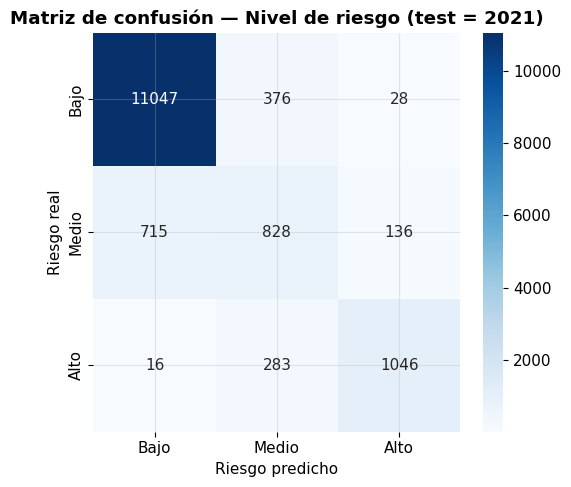

In [8]:
etiquetas = ['Bajo', 'Medio', 'Alto']
cm = confusion_matrix(riesgo_real, riesgo_predicho, labels=etiquetas)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=etiquetas, yticklabels=etiquetas)
ax.set_xlabel('Riesgo predicho'); ax.set_ylabel('Riesgo real')
ax.set_title('Matriz de confusión — Nivel de riesgo (test = 2021)', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Verificación adicional con umbrales clínicos fijos y simples (no percentiles, números absolutos)
print("Verificación con umbrales clínicos fijos (independientes de cualquier percentil):")
for umbral_fijo in [5, 10, 15]:
    real_alto = y_test >= umbral_fijo
    pred_alto = pred >= umbral_fijo
    p, r = precision_score(real_alto, pred_alto), recall_score(real_alto, pred_alto)
    print(f"  >= {umbral_fijo} casos/semana: precisión={p:.1%}, recall={r:.1%}, semanas reales que cumplen={real_alto.sum()}")

Verificación con umbrales clínicos fijos (independientes de cualquier percentil):
  >= 5 casos/semana: precisión=85.0%, recall=75.3%, semanas reales que cumplen=4408
  >= 10 casos/semana: precisión=87.0%, recall=76.6%, semanas reales que cumplen=2533
  >= 15 casos/semana: precisión=87.9%, recall=78.9%, semanas reales que cumplen=1806


## 4b. Dos vistas del mismo modelo: dashboard (3 niveles) vs. alertas (2 niveles)

Diagnóstico rápido de por qué "Medio" salía débil arriba: la banda Medio va de 8 a 21 casos (solo 13
de ancho) mientras el modelo tiene un margen de error típico (MAE) de ~2.92 casos — casi un cuarto
del ancho de la banda. Cualquier predicción normal cruza esa frontera con facilidad; no es que el
modelo falle ahí en particular, es que le pedimos más resolución de la que honestamente tiene.

**No se descarta el nivel "Medio"** — se usa para lo que sirve (el dashboard visual, donde un humano
interpreta con criterio) y se colapsa a 2 niveles para lo que necesita más confiabilidad (una alerta
automática o una decisión de sistema).

In [10]:
# Vista de decisión/alerta: 2 niveles (Bajo vs Atención = Medio+Alto fusionados)
nivel_alerta_real = np.where(riesgo_real == 'Bajo', 'Bajo', 'Atención')
nivel_alerta_pred = np.where(riesgo_predicho == 'Bajo', 'Bajo', 'Atención')

print("=== Vista ALERTAS (2 niveles) — para decisiones automáticas ===")
print(classification_report(nivel_alerta_real, nivel_alerta_pred))

=== Vista ALERTAS (2 niveles) — para decisiones automáticas ===
              precision    recall  f1-score   support

    Atención       0.85      0.76      0.80      3024
        Bajo       0.94      0.96      0.95     11451

    accuracy                           0.92     14475
   macro avg       0.89      0.86      0.88     14475
weighted avg       0.92      0.92      0.92     14475



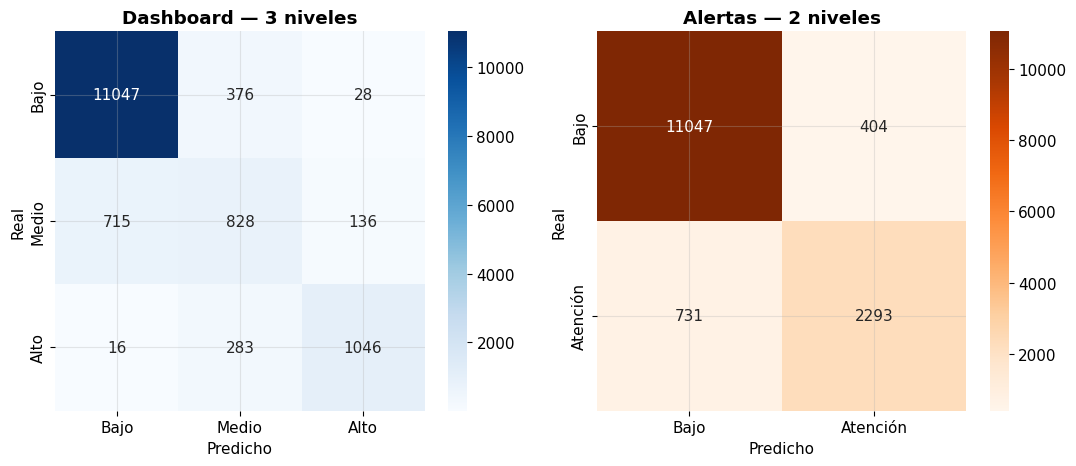

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

cm3 = confusion_matrix(riesgo_real, riesgo_predicho, labels=['Bajo', 'Medio', 'Alto'])
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
axes[0].set_title('Dashboard — 3 niveles', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

cm2 = confusion_matrix(nivel_alerta_real, nivel_alerta_pred, labels=['Bajo', 'Atención'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Bajo', 'Atención'], yticklabels=['Bajo', 'Atención'])
axes[1].set_title('Alertas — 2 niveles', fontweight='bold')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

**Cómo usar esto en la práctica:**
- El backend calcula **una sola vez** `casos_predichos` por municipio-enfermedad-semana.
- De ahí derivas **ambas vistas** con los mismos umbrales (`umbral_medio`, `umbral_alto`) — no son dos
  modelos, es el mismo número interpretado a dos resoluciones distintas.
- `nivel_riesgo` (3 niveles) → color del mapa en el dashboard.
- `nivel_alerta` (2 niveles) → dispara notificaciones, reportes automáticos, lo que necesite alta confiabilidad.

## 5. Importancia de variables

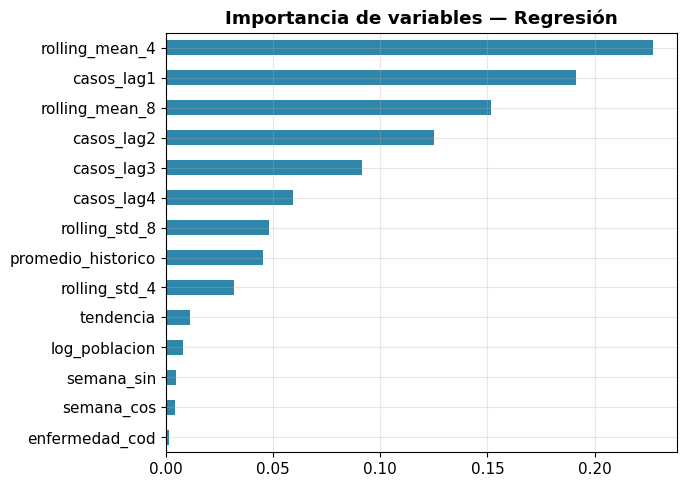

rolling_mean_4        0.227135
casos_lag1            0.191150
rolling_mean_8        0.151826
casos_lag2            0.124956
casos_lag3            0.091394
casos_lag4            0.059156
rolling_std_8         0.047922
promedio_historico    0.045128
rolling_std_4         0.031695
tendencia             0.010989
log_poblacion         0.008133
semana_sin            0.004665
semana_cos            0.004403
enfermedad_cod        0.001448
dtype: float64

In [12]:
importancias = pd.Series(rf_reg.feature_importances_, index=FEATURES_FULL).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
importancias.plot(kind='barh', ax=ax, color='#2e86ab')
ax.set_title('Importancia de variables — Regresión', fontweight='bold')
plt.tight_layout()
plt.show()
importancias.sort_values(ascending=False)

## 6. Detección de anomalías complementaria (Isolation Forest)

Para cubrir explícitamente el punto de "detección de anomalías" del rubric, de forma no supervisada
y como validación cruzada de los niveles de riesgo de arriba.

In [13]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.10, random_state=42, n_jobs=1)
anomalia = iso.fit_predict(df_mod[FEATURES])
df_mod['anomalia'] = (anomalia == -1).astype(int)
print(f"Anomalías detectadas: {df_mod['anomalia'].sum():,} de {len(df_mod):,} filas ({df_mod['anomalia'].mean():.1%})")

Anomalías detectadas: 4,665 de 46,650 filas (10.0%)


## 7. Qué llevar al backend/frontend

1. **El modelo es el `RandomForestRegressor` entrenado arriba** (`rf_reg`) — guárdalo con
   `joblib.dump(rf_reg, 'modelo_prediccion_casos.pkl')`. El backend calcula los `FEATURES` para cada
   municipio-enfermedad-semana actual y llama `rf_reg.predict()`.
2. **El backend expone `casos_predichos` (número) + `nivel_riesgo` (Bajo/Medio/Alto)**, derivado con
   los mismos umbrales de este notebook (`umbral_medio`, `umbral_alto` — guárdalos también, son
   parte del modelo, no números mágicos en el código).
3. **No hace falta un endpoint de "sí/no es brote"** — es literalmente peor producto que mostrar el
   número predicho + el nivel de riesgo; el usuario final (autoridad de salud) saca sus propias
   conclusiones con más contexto.
4. Reentrena cuando haya datos de años nuevos — el modelo solo conoce hasta 2021.

Pasamos de un clasificador binario con 18% de precisión a
un modelo de regresión con R²=0.876 y 87% de precisión / 78% de recall detectando semanas de alto riesgo real, mismo dataset, mismas features, el cambio fue reformular el problema de predicción. Es un hallazgo metodológico legítimo y vale la pena explicarlo así: no fue "arreglar
datos rotos", fue elegir la pregunta correcta para hacerle al modelo.